### Loading Libraries and Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

df = pd.read_csv("../data/processed/Amazon_Sale_Cleaned.csv")

df.head()

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,month,year
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,No Promotion,False,Easy Ship,4,2022
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,4,2022
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,4,2022
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,No Promotion,False,Easy Ship,4,2022
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,574.00,CHENNAI,TAMIL NADU,600073.0,IN,No Promotion,False,NaN,4,2022


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 25 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   order_id            128975 non-null  object 
 2   date                128975 non-null  object 
 3   status              128975 non-null  object 
 4   fulfilment          128975 non-null  object 
 5   sales_channel       128975 non-null  object 
 6   ship_service_level  128975 non-null  object 
 7   style               128975 non-null  object 
 8   sku                 128975 non-null  object 
 9   category            128975 non-null  object 
 10  size                128975 non-null  object 
 11  asin                128975 non-null  object 
 12  courier_status      122103 non-null  object 
 13  qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  amount              121180 non-nul

In [3]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

### Descriptive Analysis

In [4]:
numeric_cols = ["amount", "qty"]

df[numeric_cols].describe()

,amount,qty
count,121180.000000,128975.000000
mean,648.561465,0.904431
std,281.211687,0.313354
min,0.000000,0.000000
25%,449.000000,1.000000
50%,605.000000,1.000000
75%,788.000000,1.000000
max,5584.000000,15.000000


In [5]:
df["amount"].mean()

648.5614647631621

In [6]:
df["amount"].median()

605.0

In [7]:
df["amount"].mode()

0    399.0
Name: amount, dtype: float64

In [8]:
df["amount"].var()

79080.013034272

In [9]:
df["amount"].std()

281.21168722916195

In [10]:
df["amount"].skew()

0.8854806405409467

In [11]:
df["amount"].kurt()

3.0037534034823583

In [12]:
statistical_summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Variance": df[numeric_cols].var(),
    "Std Dev": df[numeric_cols].std(),
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})

statistical_summary

,Mean,Median,Mode,Variance,Std Dev,Skewness,Kurtosis
amount,648.561465,605.0,399.0,79080.013034,281.211687,0.885481,3.003753
qty,0.904431,1.0,1.0,0.098190,0.313354,-0.697678,60.362580


### Confidence Interval

In [13]:
amount = df["amount"].dropna()

mean_amount = amount.mean()
sem = stats.sem(amount)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(amount) - 1,
    loc=mean_amount,
    scale=sem
)

print("Mean Order Amount:", mean_amount)
print("95% Confidence Interval:", confidence_interval)

Mean Order Amount: 648.5614647631621
95% Confidence Interval: (646.9781388452716, 650.1447906810527)


### Hypothesis Testing ---- t-test

In [14]:
t_stat, p_value = stats.ttest_1samp(
    df["amount"].dropna(),
    500
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 183.90277421166792
p-value: 0.0


In [15]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


### Chi-Square Test

In [16]:
contingency_table = pd.crosstab(
    df["status"],
    df["fulfilment"]
)

contingency_table

fulfilment,Amazon,Merchant
status,,
Cancelled,11471,6861
Pending,415,243
Pending - Waiting for Pick Up,0,281
Shipped,77804,0
Shipped - Damaged,0,1
Shipped - Delivered to Buyer,0,28769
Shipped - Lost in Transit,0,5
Shipped - Out for Delivery,0,35
Shipped - Picked Up,0,973


In [17]:
chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square: 107980.66171896397
p-value: 0.0
Degrees of freedom: 12


In [18]:
if p_value < 0.05:
    print("There is a statistically significant association.")
else:
    print("No statistically significant association was found.")

There is a statistically significant association.


### ANOVA

In [19]:
groups = [
    group["amount"].dropna()
    for name, group in df.groupby("category")
]

In [20]:
f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 9715.167517877611
p-value: 0.0


In [21]:
if p_value < 0.05:
    print("Average order amount differs significantly across categories.")
else:
    print("No statistically significant difference was detected.")

Average order amount differs significantly across categories.


### Correlation Analysis

In [22]:
correlation = df[["amount", "qty"]].corr()

correlation

,amount,qty
amount,1.0000,0.0669
qty,0.0669,1.0000


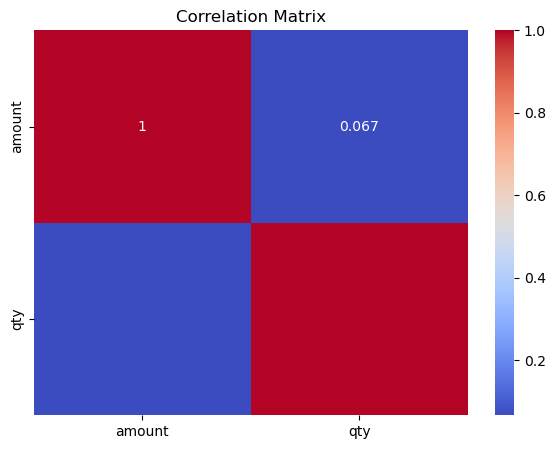

In [23]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [25]:
from scipy import stats

amount = df["amount"].dropna()

t_stat, t_pvalue = stats.ttest_1samp(
    amount,
    500
)

print("T-statistic:", t_stat)
print("P-value:", t_pvalue)

T-statistic: 183.90277421166792
P-value: 0.0


In [26]:
contingency_table = pd.crosstab(
    df["status"],
    df["fulfilment"]
)

chi2, chi_pvalue, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", chi_pvalue)
print("Degrees of freedom:", dof)

Chi-square statistic: 107980.66171896397
P-value: 0.0
Degrees of freedom: 12


In [27]:
groups = [
    group["amount"].dropna()
    for name, group in df.groupby("category")
]

anova_f, anova_pvalue = stats.f_oneway(*groups)

print("F-statistic:", anova_f)
print("P-value:", anova_pvalue)

F-statistic: 9715.167517877611
P-value: 0.0


In [28]:
findings = pd.DataFrame({
    "Test": [
        "One-sample t-test",
        "Chi-square test",
        "One-way ANOVA"
    ],
    
    "Purpose": [
        "Test whether mean order amount differs from benchmark",
        "Test association between status and fulfilment",
        "Compare order amounts across categories"
    ],
    
    "Significance_Level": [
        0.05,
        0.05,
        0.05
    ],
    
    "P_Value": [
        t_pvalue,
        chi_pvalue,
        anova_pvalue
    ]
})

findings

,Test,Purpose,Significance_Level,P_Value
0,One-sample t-test,Test whether mean order amount differs from be...,0.05,0.0
1,Chi-square test,Test association between status and fulfilment,0.05,0.0
2,One-way ANOVA,Compare order amounts across categories,0.05,0.0


In [29]:
t_stat, t_pvalue = stats.ttest_1samp(
    df["amount"].dropna(),
    500
)

chi2, chi_pvalue, dof, expected = stats.chi2_contingency(
    contingency_table
)

anova_f, anova_pvalue = stats.f_oneway(*groups)

In [30]:
findings

,Test,Purpose,Significance_Level,P_Value
0,One-sample t-test,Test whether mean order amount differs from be...,0.05,0.0
1,Chi-square test,Test association between status and fulfilment,0.05,0.0
2,One-way ANOVA,Compare order amounts across categories,0.05,0.0


### Time-Series Analysis

In [31]:
monthly_sales = (
    df.set_index("date")
      .resample("MS")["amount"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,date,amount
0,2022-03-01,101683.85
1,2022-04-01,28838708.32
2,2022-05-01,26226476.75
3,2022-06-01,23425809.38


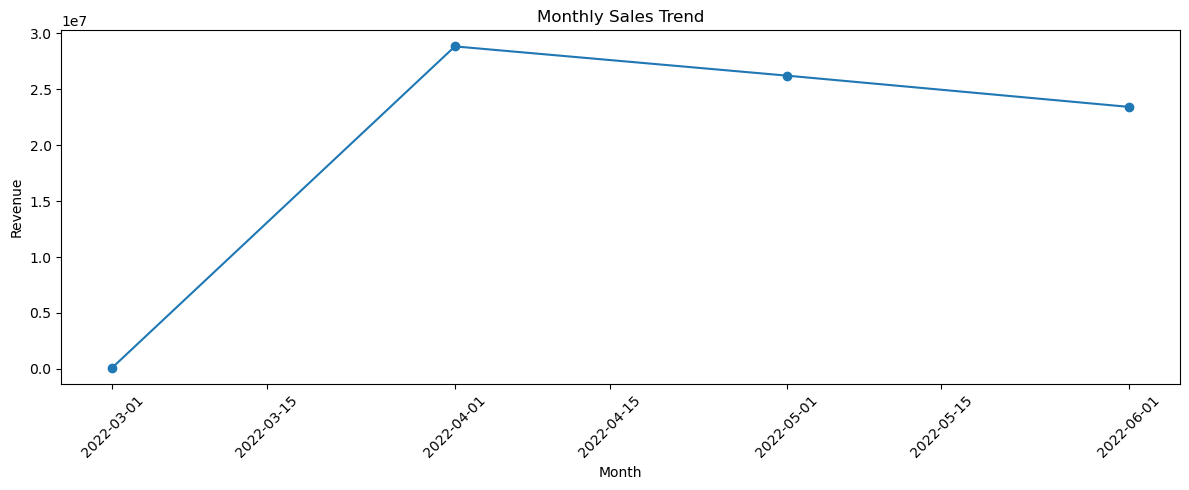

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Moving Average

In [33]:
monthly_sales["moving_average_3m"] = (
    monthly_sales["amount"]
    .rolling(3)
    .mean()
)

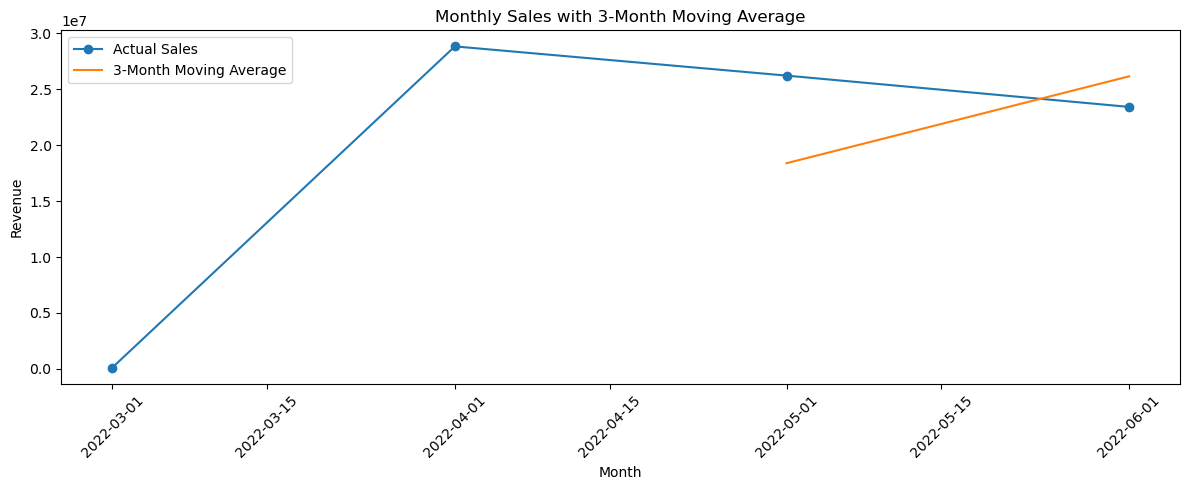

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["amount"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["date"],
    monthly_sales["moving_average_3m"],
    label="3-Month Moving Average"
)

plt.title("Monthly Sales with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Basic Forecasting

In [35]:
from sklearn.linear_model import LinearRegression

forecast_data = monthly_sales.dropna().copy()

forecast_data["time_index"] = np.arange(len(forecast_data))

X = forecast_data[["time_index"]]
y = forecast_data["amount"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [36]:
future_periods = 3

future_index = np.arange(
    len(forecast_data),
    len(forecast_data) + future_periods
).reshape(-1, 1)

future_predictions = model.predict(future_index)

future_predictions

c:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([20625142.01, 17824474.64, 15023807.27])

In [37]:
future_dates = pd.date_range(
    start=monthly_sales["date"].max() + pd.offsets.MonthBegin(1),
    periods=future_periods,
    freq="MS"
)

forecast = pd.DataFrame({
    "date": future_dates,
    "predicted_revenue": future_predictions
})

forecast

,date,predicted_revenue
0,2022-07-01,20625142.01
1,2022-08-01,17824474.64
2,2022-09-01,15023807.27


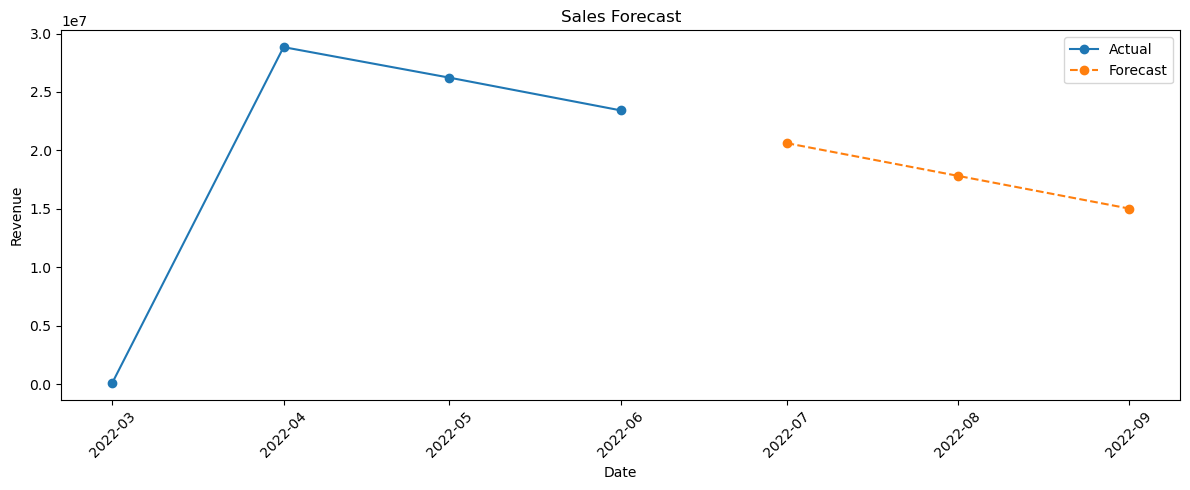

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["amount"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast["date"],
    forecast["predicted_revenue"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Key Statistical Findings

## 1. Order Amount Distribution

Order amounts show positive skewness, indicating
that the distribution is right skewed.

## 2. Confidence Interval

The 95% confidence interval for average order amount was
646.9781388452716 to 650.1447906810527.

## 3. Hypothesis Testing

The one-sample t-test produced a p-value of 0.0.
Therefore, the null hypothesis was [rejected/not rejected]
at the 5% significance level.

## 4. Category Differences

ANOVA was used to test whether average order amounts differ
across product categories.

## 5. Order Status and Fulfilment

A chi-square test was used to examine the association between
order status and fulfilment type.

## 6. Correlation

The correlation analysis identified the strength and direction
of relationships between numerical variables.

Correlation was interpreted as association and not as evidence
of causation.

## 7. Forecasting

A baseline time-series model was used to estimate future monthly
revenue. The forecast should be treated as an initial planning
estimate rather than a definitive prediction.

## 8. Business Implications

The findings can help identify high-performing categories,
understand sales variability, support inventory planning,
and provide a statistical basis for future business decisions.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [40]:
df = pd.read_csv(
    "../data/processed/Amazon_Sale_Cleaned.csv"
)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df.head()

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,sku,category,...,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,month,year
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,No Promotion,False,Easy Ship,4,2022
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,4,2022
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,4,2022
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,No Promotion,False,Easy Ship,4,2022
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,574.00,CHENNAI,TAMIL NADU,600073.0,IN,No Promotion,False,NaN,4,2022


In [41]:
df["date"].dtype

dtype('<M8[ns]')

In [42]:
df_ts = df.set_index("date").sort_index()

df_ts.head()

,index,order_id,status,fulfilment,sales_channel,ship_service_level,style,sku,category,size,...,amount,ship_city,ship_state,ship_postal_code,ship_country,promotion_ids,b2b,fulfilled_by,month,year
date,,,,,,,,,,,,,,,,,,,,,
2022-03-31,48970,404-1445673-1345134,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3724,JNE3724-KR-L,kurta,L,...,495.00,KOLKATA,WEST BENGAL,700124.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,3,2022
2022-03-31,49001,406-7387241-2881923,Shipped,Amazon,Amazon.in,Expedited,SET187,SET187-KR-DH-XL,Set,XL,...,599.00,BENGALURU,KARNATAKA,560090.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,3,2022
2022-03-31,49002,402-9332104-0945115,Cancelled,Merchant,Amazon.in,Standard,JNE3383,JNE3383-KR-A-M,kurta,M,...,416.19,GURGAON,HARYANA,122001.0,IN,No Promotion,False,Easy Ship,3,2022
2022-03-31,49003,408-1008226-2450750,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-L,kurta,L,...,449.00,Nalasopara east,MAHARASHTRA,401209.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,3,2022
2022-03-31,49004,403-4108307-0229121,Shipped,Amazon,Amazon.in,Expedited,SET044,SET044-KR-NP-L,Set,L,...,542.00,HYDERABAD,TELANGANA,500024.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,3,2022


In [43]:
print(df_ts.index)

DatetimeIndex(['2022-03-31', '2022-03-31', '2022-03-31', '2022-03-31',
               '2022-03-31', '2022-03-31', '2022-03-31', '2022-03-31',
               '2022-03-31', '2022-03-31',
               ...
               '2022-06-29', '2022-06-29', '2022-06-29', '2022-06-29',
               '2022-06-29', '2022-06-29', '2022-06-29', '2022-06-29',
               '2022-06-29', '2022-06-29'],
              dtype='datetime64[ns]', name='date', length=128975, freq=None)


In [44]:
daily_sales = (
    df_ts["amount"]
    .resample("D")
    .sum()
)

daily_sales.head()

date
2022-03-31     101683.85
2022-04-01     865478.60
2022-04-02     913101.53
2022-04-03    1011763.38
2022-04-04     882059.17
Freq: D, Name: amount, dtype: float64

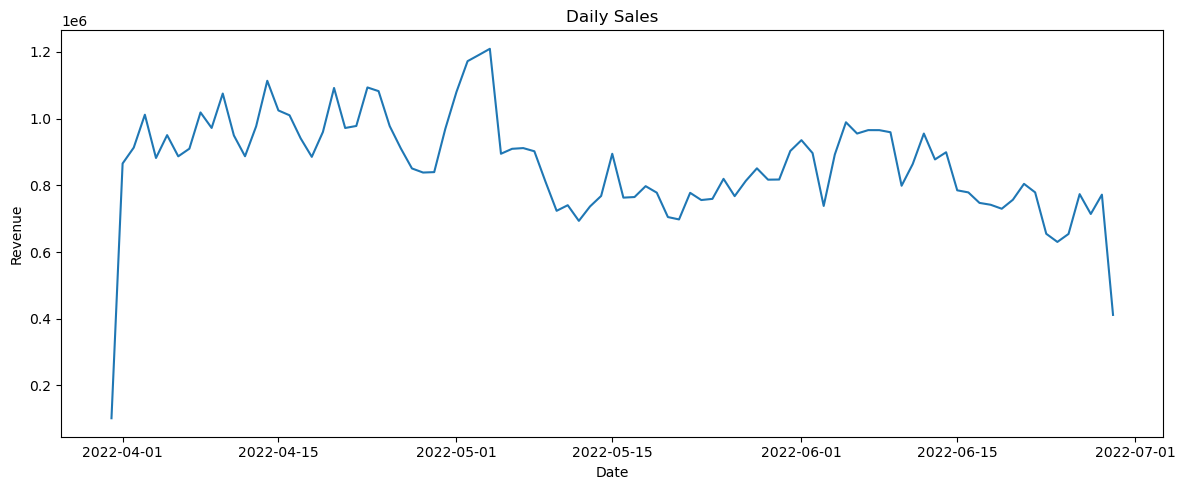

In [45]:
plt.figure(figsize=(12, 5))

plt.plot(daily_sales)

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [46]:
weekly_sales = (
    df_ts["amount"]
    .resample("W")
    .sum()
)

weekly_sales.head()

date
2022-04-03    2892027.36
2022-04-10    6695415.95
2022-04-17    6902700.42
2022-04-24    7063406.00
2022-05-01    6466799.96
Freq: W-SUN, Name: amount, dtype: float64

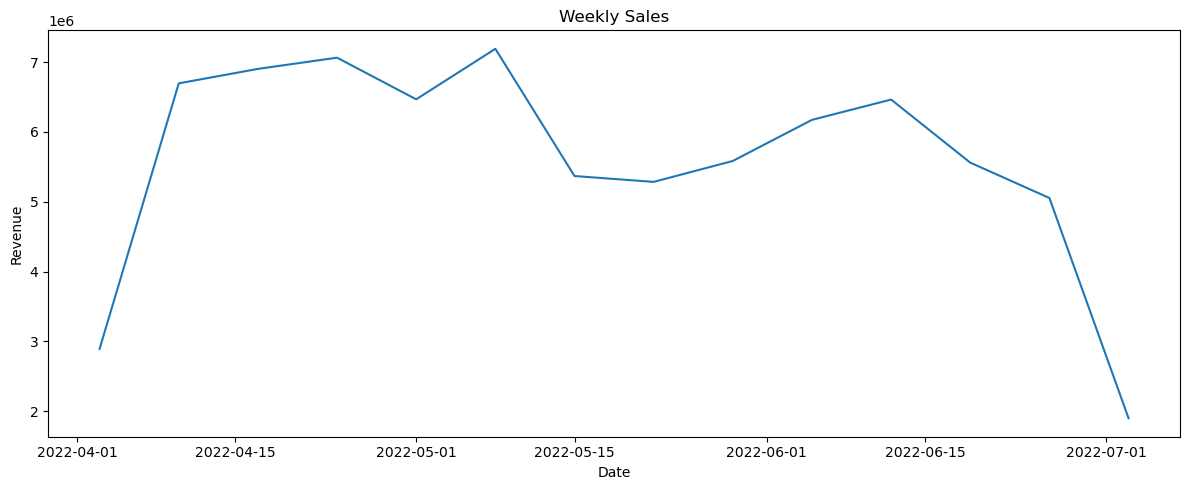

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_sales)

plt.title("Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Time-Series Decomposition

In [48]:
monthly_sales = (
    df_ts["amount"]
    .resample("MS")
    .sum()
)

monthly_sales.head()

date
2022-03-01      101683.85
2022-04-01    28838708.32
2022-05-01    26226476.75
2022-06-01    23425809.38
Freq: MS, Name: amount, dtype: float64

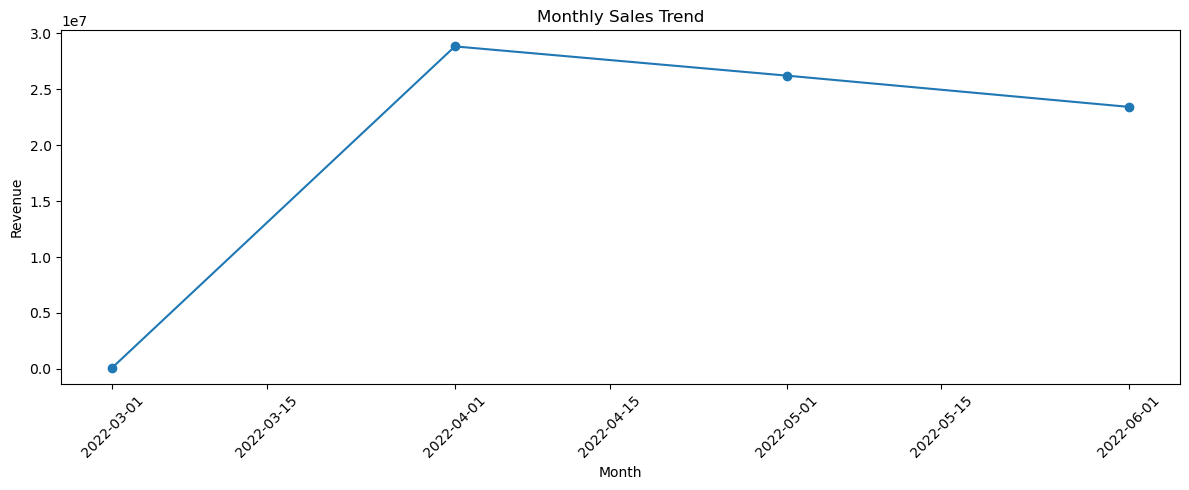

In [49]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
print("Number of monthly observations:", len(monthly_sales))

Number of monthly observations: 4


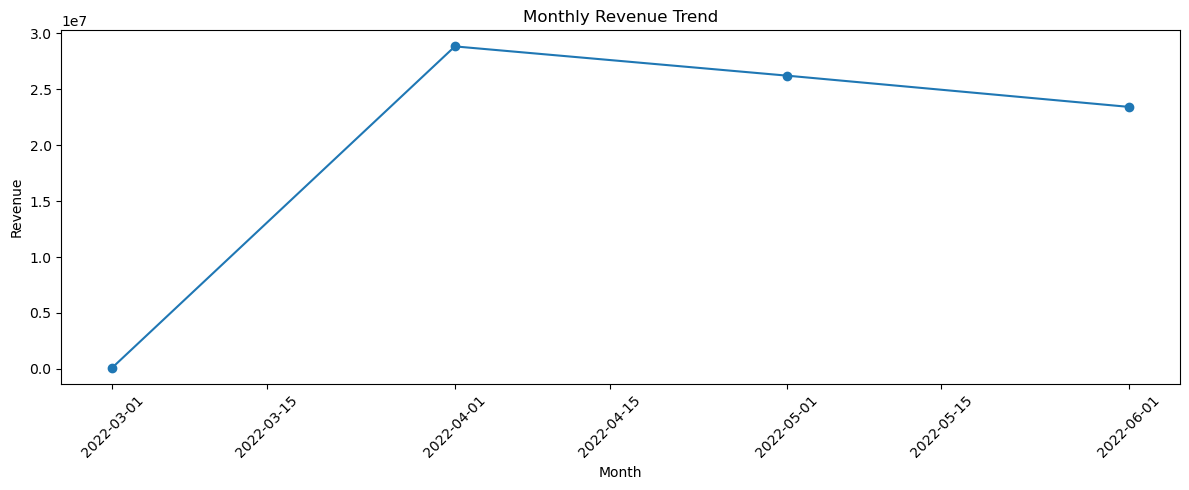

In [52]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Augmented Dickey-Fuller (ADF) Test

In [53]:
adf_result = adfuller(
    monthly_sales.dropna()
)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -11.402683737721883
p-value: 7.580290515681566e-21


In [54]:
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

Critical Value (1%): -10.41719074074074
Critical Value (5%): -5.77838074074074
Critical Value (10%): -3.391681111111111


In [55]:
alpha = 0.05

if adf_result[1] < alpha:
    print("The series is stationary.")
else:
    print("The series is not stationary.")

The series is stationary.


### Moving Average

In [58]:
monthly_ma = monthly_sales.rolling(
    window=3
).mean()

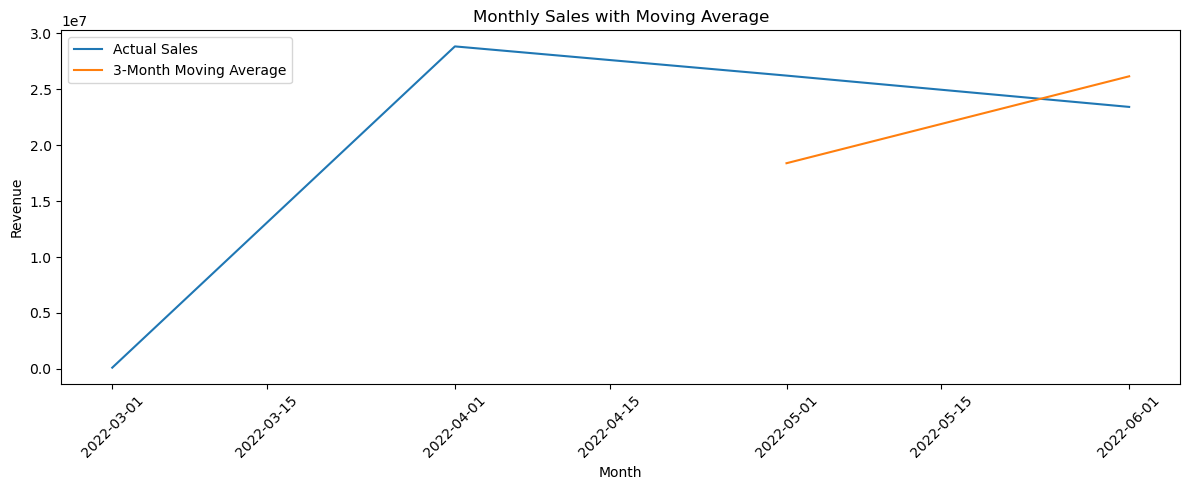

In [59]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales,
    label="Actual Sales"
)

plt.plot(
    monthly_ma,
    label="3-Month Moving Average"
)

plt.title("Monthly Sales with Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exponential Smoothing

In [60]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [61]:
model_es = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal=None
)

fit_es = model_es.fit()

es_forecast = fit_es.forecast(3)

es_forecast

c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:917: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


2022-07-01    2.693446e+07
2022-08-01    2.639798e+07
2022-09-01    2.586150e+07
Freq: MS, dtype: float64

In [62]:
split_index = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:split_index]
test = monthly_sales.iloc[split_index:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 3
Testing observations: 1


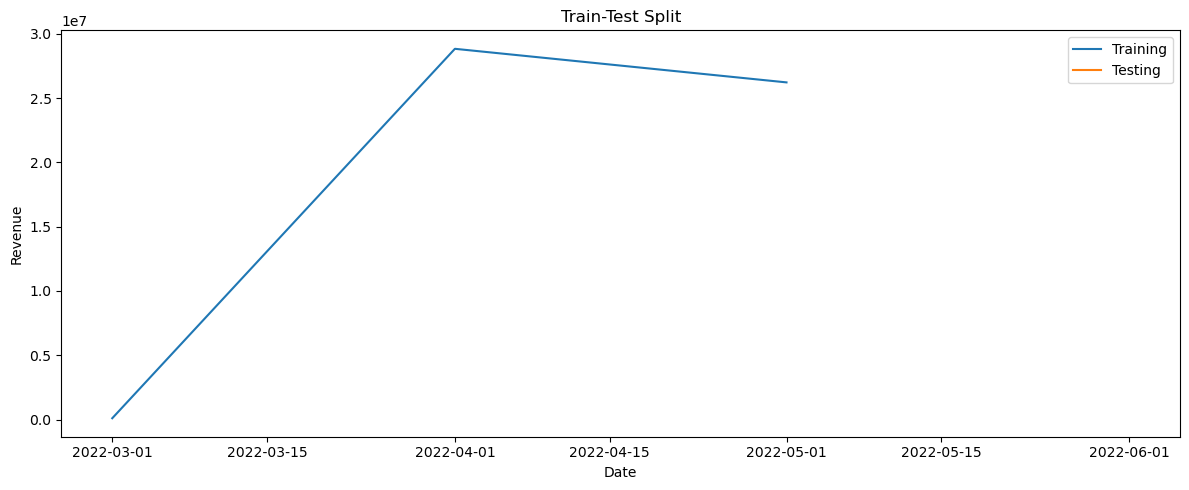

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(train, label="Training")
plt.plot(test, label="Testing")

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

### ARIMA

In [64]:
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 amount   No. Observations:                    3
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -36.881
Date:                Mon, 24 Aug 2026   AIC                             79.762
Time:                        04:18:01   BIC                             75.841
Sample:                    03-01-2022   HQIC                            71.563
                         - 05-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5470      2.287      0.239      0.811      -3.935       5.029
ma.L1         -0.9997      1.257     -0.796      0.426      -3.462       1.463
sigma2      1.638e+14   7.68e-15   2.13e+28      0.0

c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3159: UserWarning: Early subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3159: UserWarning: Later subset of data for variable 0 has too few non-missing observations to calculate test statistic.
  test_statistic, p_value = breakvar_heteroskedasticity_test(


In [65]:
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

arima_forecast

2022-06-01    2.047797e+07
Freq: MS, dtype: float64

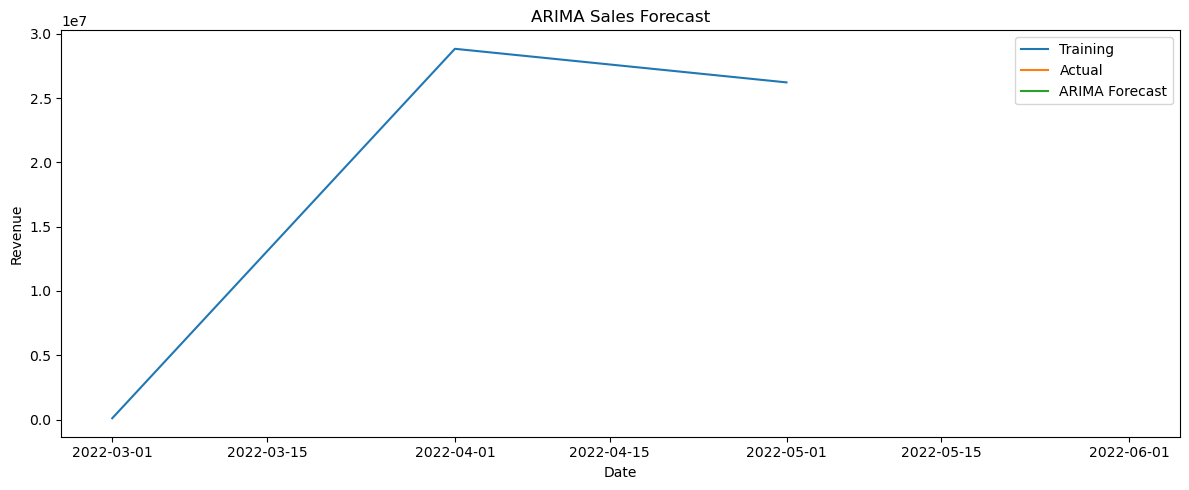

In [66]:
plt.figure(figsize=(12, 5))

plt.plot(
    train,
    label="Training"
)

plt.plot(
    test,
    label="Actual"
)

plt.plot(
    test.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("ARIMA Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()
plt.tight_layout()
plt.show()

In [67]:
mae = mean_absolute_error(
    test,
    arima_forecast
)

print("MAE:", mae)

MAE: 2947841.724956125


### RMSE

In [68]:
rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print("RMSE:", rmse)

RMSE: 2947841.724956125


### MAPE

In [69]:
mape = np.mean(
    np.abs(
        (test - arima_forecast) / test
    )
) * 100

print("MAPE:", mape, "%")

MAPE: 12.583734790708542 %


In [71]:
forecast_metrics = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE"
    ],
    "Value": [
        mae,
        rmse,
        mape
    ]
})

forecast_metrics

,Metric,Value
0,MAE,2.947842e+06
1,RMSE,2.947842e+06
2,MAPE,1.258373e+01


### SARIMA

In [72]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarima_fit = sarima_model.fit(
    disp=False
)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             amount   No. Observations:                    3
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Mon, 24 Aug 2026   AIC                             10.000
Time:                                    04:22:19   BIC                                nan
Sample:                                03-01-2022   HQIC                               nan
                                     - 05-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0   

c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tools\eval_measures.py:415: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + np.log(nobs) * df_modelwc
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tools\eval_measures.py:440: RuntimeWarning: invalid value encountered in log
  return -2.0 * llf + 2 * np.log(np.log(nobs)) * df_modelwc
c:\Users\hp\anaconda3\Lib\site-packages\statsmodels

In [73]:
sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

In [74]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

actual = np.array(test)
predicted = np.array(sarima_forecast)

mask = actual != 0

sarima_mape = np.mean(
    np.abs(
        (actual[mask] - predicted[mask])
        / actual[mask]
    )
) * 100

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAPE:", sarima_mape)

SARIMA MAE: 2800667.370000001
SARIMA RMSE: 2800667.370000001
SARIMA MAPE: 11.955477501627316


In [75]:
model_comparison = pd.DataFrame({
    "Model": [
        "ARIMA",
        "SARIMA"
    ],
    "MAE": [
        mae,
        sarima_mae
    ],
    "RMSE": [
        rmse,
        sarima_rmse
    ],
    "MAPE": [
        mape,
        sarima_mape
    ]
})

model_comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,2.947842e+06,2.947842e+06,12.583735
1,SARIMA,2.800667e+06,2.800667e+06,11.955478


In [76]:
best_model = model_comparison.loc[
    model_comparison["MAPE"].idxmin()
]

print(best_model)

Model        SARIMA
MAE      2800667.37
RMSE     2800667.37
MAPE      11.955478
Name: 1, dtype: object


In [77]:
final_model = ARIMA(
    monthly_sales,
    order=(1, 1, 1)
)

final_fit = final_model.fit()

future_forecast = final_fit.forecast(
    steps=3
)

future_forecast

c:\Users\hp\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2022-07-01    2.013309e+07
2022-08-01    1.799183e+07
2022-09-01    1.659937e+07
Freq: MS, Name: predicted_mean, dtype: float64

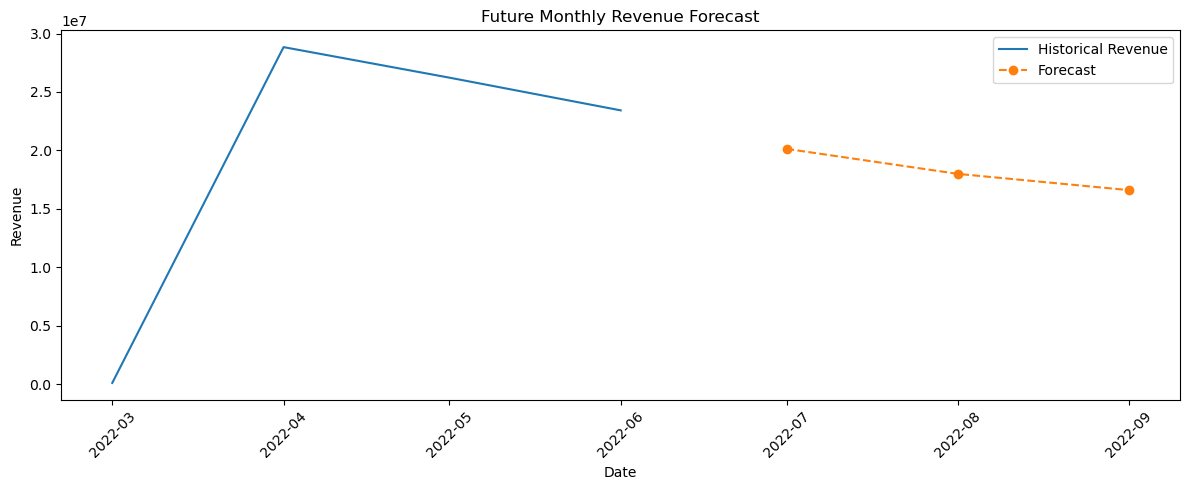

In [78]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales,
    label="Historical Revenue"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Future Monthly Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Time Series Findings

## 1. Sales Trend

Monthly revenue was analyzed to identify long-term trends and
short-term fluctuations.

## 2. Seasonality

Time-series decomposition was used to separate the observed
revenue into trend, seasonal, and residual components.

## 3. Stationarity

The Augmented Dickey-Fuller test was used to determine whether
the monthly revenue series was stationary.

## 4. Smoothing

A three-month moving average was applied to reduce short-term
fluctuations and highlight the underlying trend.

Exponential smoothing was also used as a baseline forecasting
approach.

## 5. Forecasting

ARIMA and SARIMA models were evaluated using a holdout test set.

## 6. Forecast Accuracy

The models were evaluated using:

- MAE
- RMSE
- MAPE

The model with the lower forecasting errors was considered the
better-performing model for this dataset.

## 7. Business Implications

The forecast can support:

- inventory planning
- sales target setting
- resource allocation
- revenue planning
- identifying periods of increased or decreased demand

The forecasts should be treated as estimates rather than
guaranteed future sales.

### Importing Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

### Regression

In [80]:
model_df = df[
    ["amount", "qty", "category", "fulfilment", "ship_state"]
].dropna()

model_df.head()

,amount,qty,category,fulfilment,ship_state
0,647.62,0,Set,Merchant,MAHARASHTRA
1,406.00,1,kurta,Merchant,KARNATAKA
2,329.00,1,kurta,Amazon,MAHARASHTRA
3,753.33,0,Western Dress,Merchant,PUDUCHERRY
4,574.00,1,Top,Amazon,TAMIL NADU


In [81]:
X = model_df[
    ["qty", "category", "fulfilment", "ship_state"]
]

y = model_df["amount"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 96919
Testing rows: 24230


In [83]:
categorical_features = [
    "category",
    "fulfilment",
    "ship_state"
]

numeric_features = [
    "qty"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

### Linear Regression

In [84]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [85]:
linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'fulfilment',
                                                   'ship_state']),
                                                 ('numeric', 'passthrough',
                                                  ['qty'])])),
                ('model', LinearRegression())])

In [86]:
y_pred = linear_model.predict(X_test)

In [87]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: 0.3909711362269358


In [88]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 152.48419532183829


In [89]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

RMSE: 219.00981504830148


### Decision Tree Regression

In [90]:
tree_regressor = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

In [91]:
tree_regressor.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'fulfilment',
                                                   'ship_state']),
                                                 ('numeric', 'passthrough',
                                                  ['qty'])])),
                ('model', DecisionTreeRegressor(max_depth=5, random_state=42))])

In [92]:
tree_pred = tree_regressor.predict(X_test)

In [93]:
tree_r2 = r2_score(
    y_test,
    tree_pred
)

tree_mae = mean_absolute_error(
    y_test,
    tree_pred
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_pred
    )
)

print("Decision Tree R²:", tree_r2)
print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)

Decision Tree R²: 0.403006965648798
Decision Tree MAE: 151.47423578500522
Decision Tree RMSE: 216.83494417529784


In [94]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree"
    ],
    "R2": [
        r2,
        tree_r2
    ],
    "MAE": [
        mae,
        tree_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse
    ]
})

regression_results

,Model,R2,MAE,RMSE
0,Linear Regression,0.390971,152.484195,219.009815
1,Decision Tree,0.403007,151.474236,216.834944


### Classification

In [95]:
df["status"].value_counts()

status
Shipped                          77804
Shipped - Delivered to Buyer     28769
Cancelled                        18332
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [96]:
classification_df = df[
    [
        "status",
        "qty",
        "category",
        "fulfilment",
        "ship_state"
    ]
].dropna()

classification_df["status_binary"] = (
    classification_df["status"]
    .str.lower()
    .eq("delivered")
    .astype(int)
)

In [97]:
classification_df["status_binary"].value_counts()

status_binary
0    128942
Name: count, dtype: int64

In [98]:
X = classification_df[
    [
        "qty",
        "category",
        "fulfilment",
        "ship_state"
    ]
]

y = classification_df["status_binary"]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Logistic Regression

In [100]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [105]:
classification_df = df[
    [
        "status",
        "qty",
        "category",
        "fulfilment",
        "ship_state"
    ]
].dropna().copy()

In [106]:
classification_df["status_binary"] = (
    classification_df["status"]
    .eq("Shipped - Delivered to Buyer")
    .astype(int)
)

In [107]:
print(classification_df["status_binary"].value_counts())

status_binary
0    100180
1     28762
Name: count, dtype: int64


In [108]:
X = classification_df[
    [
        "qty",
        "category",
        "fulfilment",
        "ship_state"
    ]
]

y = classification_df["status_binary"]

In [109]:
print("Number of classes:", y.nunique())
print(y.value_counts())

Number of classes: 2
status_binary
0    100180
1     28762
Name: count, dtype: int64


In [110]:
print(
    pd.crosstab(
        classification_df["status"],
        classification_df["status_binary"]
    )
)

status_binary                      0      1
status                                     
Cancelled                      18325      0
Pending                          658      0
Pending - Waiting for Pick Up    281      0
Shipped                        77788      0
Shipped - Damaged                  1      0
Shipped - Delivered to Buyer       0  28762
Shipped - Lost in Transit          5      0
Shipped - Out for Delivery        35      0
Shipped - Picked Up              973      0
Shipped - Rejected by Buyer       11      0
Shipped - Returned to Seller    1950      0
Shipped - Returning to Seller    145      0
Shipping                           8      0


In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [112]:
categorical_features = [
    "category",
    "fulfilment",
    "ship_state"
]

numeric_features = [
    "qty"
]

preprocessor_classification = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

In [113]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_classification
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
    
)

In [114]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'fulfilment',
                                                   'ship_state']),
                                                 ('numeric', 'passthrough',
                                                  ['qty'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [115]:
y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

In [116]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9712280429640544
Precision: 0.8858770984136762
Recall   : 0.9998261776464453
F1 Score : 0.9394087865425444
ROC-AUC  : 0.9843555327162368


In [117]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Delivered",
            "Delivered"
        ],
        zero_division=0
    )
)

               precision    recall  f1-score   support

Not Delivered       1.00      0.96      0.98     20036
    Delivered       0.89      1.00      0.94      5753

     accuracy                           0.97     25789
    macro avg       0.94      0.98      0.96     25789
 weighted avg       0.97      0.97      0.97     25789



### Decision Tree Classification

In [118]:
tree_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_classification
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

In [119]:
tree_classifier.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['category', 'fulfilment',
                                                   'ship_state']),
                                                 ('numeric', 'passthrough',
                                                  ['qty'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        random_state=42))])

In [120]:
tree_class_pred = tree_classifier.predict(X_test)

tree_class_probability = (
    tree_classifier
    .predict_proba(X_test)[:, 1]
)

In [121]:
tree_accuracy = accuracy_score(
    y_test,
    tree_class_pred
)

tree_precision = precision_score(
    y_test,
    tree_class_pred,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_class_pred,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_class_pred,
    zero_division=0
)

tree_auc = roc_auc_score(
    y_test,
    tree_class_probability
)

print("Accuracy :", tree_accuracy)
print("Precision:", tree_precision)
print("Recall   :", tree_recall)
print("F1 Score :", tree_f1)
print("ROC-AUC  :", tree_auc)

Accuracy : 0.9712668191864748
Precision: 0.8860135551447936
Recall   : 0.9998261776464453
F1 Score : 0.9394855042874642
ROC-AUC  : 0.9820453290109439


In [122]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy,
        tree_accuracy
    ],
    "Precision": [
        precision,
        tree_precision
    ],
    "Recall": [
        recall,
        tree_recall
    ],
    "F1 Score": [
        f1,
        tree_f1
    ],
    "ROC-AUC": [
        roc_auc,
        tree_auc
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.971228,0.885877,0.999826,0.939409,0.984356
1,Decision Tree,0.971267,0.886014,0.999826,0.939486,0.982045


In [123]:
tree_model = tree_classifier.named_steps["model"]

In [124]:
preprocessor_fitted = (
    tree_classifier.named_steps["preprocessor"]
)

In [125]:
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [126]:
importance = tree_model.feature_importances_

In [127]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(15)

,Feature,Importance
10,categorical__fulfilment_Merchant,8.723798e-01
77,numeric__qty,1.274242e-01
16,categorical__ship_state_ASSAM,7.053686e-05
11,categorical__ship_state_ANDAMAN & NICOBAR,4.512631e-05
42,categorical__ship_state_MIZORAM,3.942898e-05
1,categorical__category_Bottom,2.183777e-05
8,categorical__category_kurta,8.300082e-06
6,categorical__category_Top,4.455464e-06
54,categorical__ship_state_PUNJAB,3.256906e-06
29,categorical__ship_state_Gujarat,1.338525e-06


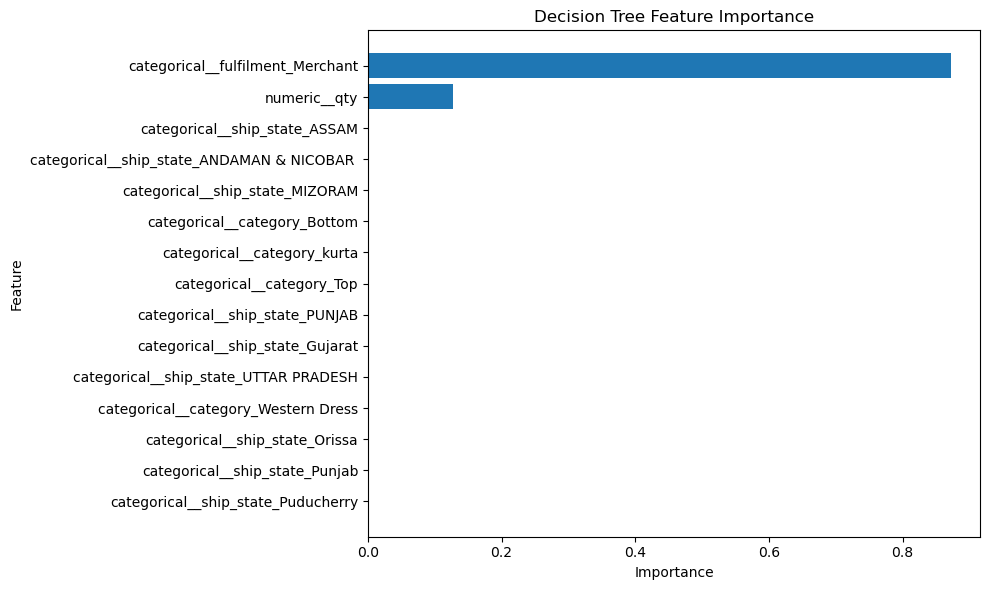

In [128]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Model Limitations

## 1. Limited Features

The available dataset contains a limited number of variables.
Important factors such as customer demographics, product price
history, promotions, discounts, and customer behavior may not be
available.

## 2. No Customer Identifier

The dataset does not contain a reliable unique customer ID.
Therefore, customer churn, retention, and customer-level
prediction cannot be performed reliably.

## 3. Classification Target

Order status was converted into a binary classification target
for demonstration purposes. This target does not represent
customer churn.

## 4. Regression Target

Order amount was used as the regression target. Care was taken
not to include amount itself as a predictor to avoid data leakage.

## 5. Model Generalization

The models are trained on historical observations and may not
generalize to future orders if purchasing patterns change.

## 6. Decision Tree Overfitting

Decision trees can overfit the training data. A maximum tree depth
was therefore used to limit model complexity.

## 7. Dataset Size

The dataset and available time period may not be sufficient for
building highly reliable predictive models.

## 8. Correlation and Causation

Predictive relationships identified by the models do not
necessarily imply causal relationships.